In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for prettier plot

sns.set_theme(style="whitegrid")

In [7]:
file_path = "/Users/mac/Desktop/apk/apk_ml_model/csv/feature_vectors_syscallsbinders_frequency_5_Cat.csv"

# loading dataset 
df = pd.read_csv(file_path)

# previewing the first rows
df.head()

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,37,10,1
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,2,2838,46,1
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,1,111,20,1
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,7,987,197,1
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,1,98,25,1


In [8]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nClass distribution:")
print(df['Class'].value_counts())

Shape of dataset: (11598, 471)

Column names:
['ACCESS_PERSONAL_INFO___', 'ALTER_PHONE_STATE___', 'ANTI_DEBUG_____', 'CREATE_FOLDER_____', 'CREATE_PROCESS`_____', 'CREATE_THREAD_____', 'DEVICE_ACCESS_____', 'EXECUTE_____', 'FS_ACCESS____', 'FS_ACCESS()____', 'FS_ACCESS(CREATE)____', 'FS_ACCESS(CREATE__APPEND)__', 'FS_ACCESS(CREATE__READ)__', 'FS_ACCESS(CREATE__READ__WRITE)', 'FS_ACCESS(CREATE__WRITE)__', 'FS_ACCESS(CREATE__WRITE__APPEND)', 'FS_ACCESS(READ)____', 'FS_ACCESS(READ__WRITE)__', 'FS_ACCESS(WRITE)____', 'FS_PIPE_ACCESS___', 'FS_PIPE_ACCESS()___', 'FS_PIPE_ACCESS(READ)___', 'FS_PIPE_ACCESS(READ__)_', 'FS_PIPE_ACCESS(READ__WRITE)_', 'FS_PIPE_ACCESS(WRITE)___', 'NETWORK_ACCESS____', 'NETWORK_ACCESS()____', 'NETWORK_ACCESS(READ)____', 'NETWORK_ACCESS(READ__WRITE)__', 'NETWORK_ACCESS(READ__WRITE__)', 'NETWORK_ACCESS(WRITE)____', 'NETWORK_ACCESS(WRITE__)__', 'SMS_SEND____', 'TERMINATE_PROCESS', 'TERMINATE_THREAD', '__arm_nr_cacheflush', '__arm_nr_set_tls', '_llseek', '_newselect', 

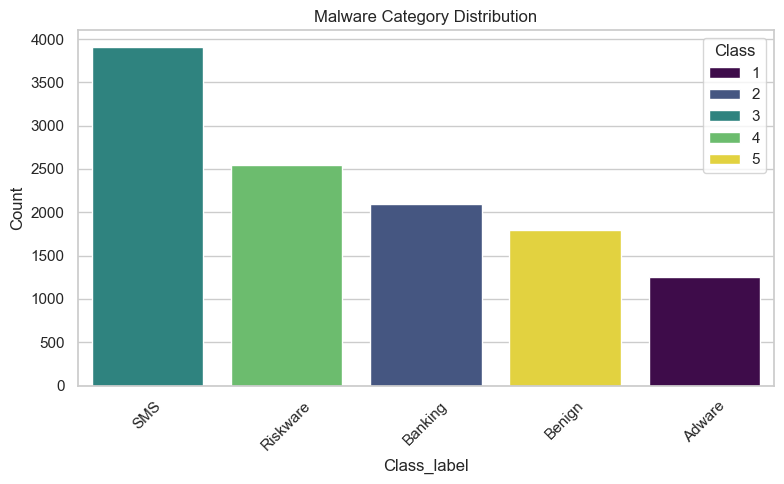

In [9]:
# lable map
label_map = {
    1: "Adware",
    2: "Banking",
    3: "SMS",
    4: "Riskware",
    5: "Benign"
}
# mapping the numeric values in the 'Class' column to the labels
df['Class_label'] = df['Class'].map(label_map)

plt.figure(figsize=(8, 5))
sns.countplot(x='Class_label', data=df, order=df['Class_label'].value_counts().index, palette="viridis", hue="Class")
plt.title("Malware Category Distribution")
plt.xlabel("Class_label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
df.head()

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class,Class_label
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,37,10,1,Adware
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,2,2838,46,1,Adware
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,1,111,20,1,Adware
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,7,987,197,1,Adware
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,1,98,25,1,Adware


In [11]:
X = df.drop(columns=['Class', 'Class_label'])  # All system/binder features
y = df['Class']                 # Target labels (1–5)

X.head()

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,updateServiceLocation,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,0,37,10
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,0,2,2838,46
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,0,1,111,20
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,0,7,987,197
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,0,1,98,25


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)



In [13]:
label_map = {
    1: "Adware", 2: "Banking", 3: "SMS",
    4: "Riskware", 5: "Benign"
}

print(y_train.value_counts().sort_index().rename(index=label_map))

X_train.head()

Class
Adware      1002
Banking     1680
SMS         3123
Riskware    2037
Benign      1436
Name: count, dtype: int64


,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,updateServiceLocation,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev
6227,3549,0,0,2,0,10,2,0,16,0,...,0,0,0,0,0,0,0,5,475,45
3009,1,0,0,0,0,8,2,0,4,0,...,0,0,0,0,0,0,0,0,28,5
994,1,0,0,0,0,18,2,0,16,0,...,0,0,0,0,0,0,0,3,204,14
2778,12,0,0,3,1,14,26,1,26,1,...,0,0,0,0,0,1,0,0,955,33
8345,0,0,0,0,0,8,37,0,45,0,...,0,0,0,0,0,0,0,0,95,4


In [14]:
# feature scalling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler on the training data and transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# checking the distribution
import numpy as np
# should be closer to 0
print("Mean (train):", np.mean(X_train_scaled))
# should be close to 1
print("Std (train):", np.std(X_train_scaled))

Mean (train): 4.8459501455067306e-18
Std (train): 0.9893045053244831


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Intializing the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# fiting and training the model
rf_model.fit(X_train_scaled,y_train)


RandomForestClassifier(random_state=42)

In [17]:
# predicting the test data

y_pred = rf_model.predict(X_test_scaled)

In [18]:
# Evaluating the model

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# label map
label_map = {
    1: "Adware", 2: "Banking", 3: "SMS",
    4: "Riskware", 5: "Benign"
}

# classification report 
target_names = [label_map[i] for i in sorted(label_map)]

print("Classification Report:")
print(classification_report(y_test,y_pred, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

      Adware       0.86      0.93      0.89       251
     Banking       0.97      0.90      0.93       420
         SMS       0.98      0.99      0.98       781
    Riskware       0.96      0.92      0.94       509
      Benign       0.91      0.95      0.93       359

    accuracy                           0.95      2320
   macro avg       0.93      0.94      0.94      2320
weighted avg       0.95      0.95      0.95      2320



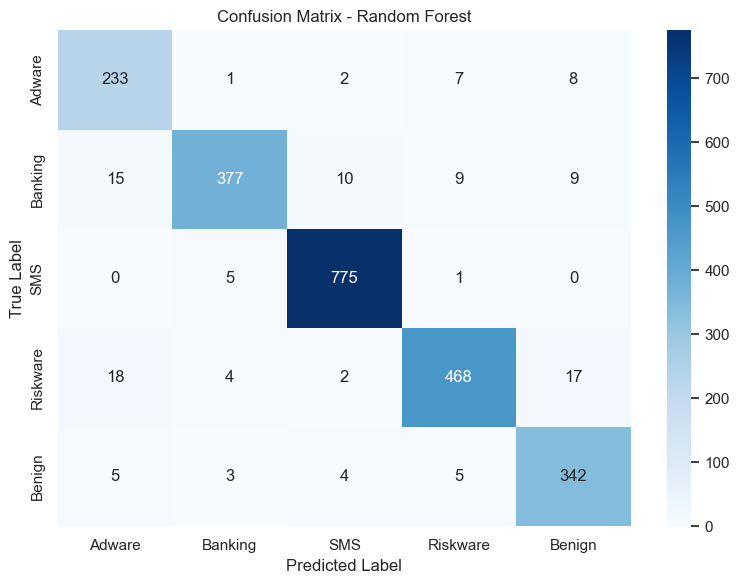


The confusion matrix visualizes the performance of the Random Forest model on the test dataset.
- Rows represent the true labels (actual classes).
- Columns represent the predicted labels (model's predictions).
- Each cell (i, j) shows the number of instances where the true label was i and the predicted label was j.

Diagonal values (top-left to bottom-right) indicate correct predictions, while off-diagonal values represent misclassifications.
For example:
- The top-left cell shows the number of correctly classified 'Adware' samples.
- The bottom-right cell shows the number of correctly classified 'Benign' samples.
- Off-diagonal cells, such as (1, 2), indicate 'Adware' samples misclassified as 'Banking'.

This graph helps identify which classes the model performs well on and where it struggles.



In [19]:
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Explanation
print("""
The confusion matrix visualizes the performance of the Random Forest model on the test dataset.
- Rows represent the true labels (actual classes).
- Columns represent the predicted labels (model's predictions).
- Each cell (i, j) shows the number of instances where the true label was i and the predicted label was j.

Diagonal values (top-left to bottom-right) indicate correct predictions, while off-diagonal values represent misclassifications.
For example:
- The top-left cell shows the number of correctly classified 'Adware' samples.
- The bottom-right cell shows the number of correctly classified 'Benign' samples.
- Off-diagonal cells, such as (1, 2), indicate 'Adware' samples misclassified as 'Banking'.

This graph helps identify which classes the model performs well on and where it struggles.
""")

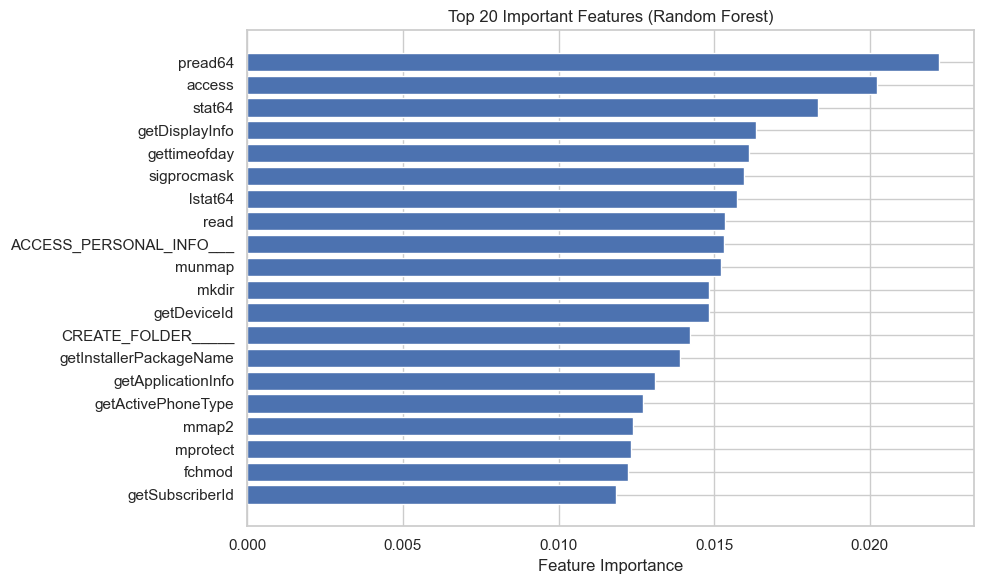

In [20]:
import numpy as np

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Sort top N important features
N = 20
indices = np.argsort(importances)[-N:]

plt.figure(figsize=(10, 6))
plt.barh(range(N), importances[indices], align='center')
plt.yticks(range(N), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title(f"Top {N} Important Features (Random Forest)")
plt.tight_layout()
plt.show()



In [21]:
# exporting the model

import joblib

# Save the model to a file
joblib.dump(rf_model, 'apk_forest_model.pkl')

# saving the scaler
joblib.dump(scaler, 'apk_forest_scaler.pkl')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [22]:
# Deep Learning Model with TensorFlow

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


# convert int to one-hot encoding format
num_classes = 5
y_train_oh = to_categorical(y_train -1, num_classes=num_classes)
y_test_oh = to_categorical(y_test-1, num_classes=num_classes)


2025-05-12 12:24:55.135414: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [23]:
# sequential is a model that allows you to build a model layer by layer


model = Sequential([

    Input(shape=(X_train_scaled.shape[1],)),
    # First hidden layer with 256 neurons and ReLU activation
    Dense(256, activation='relu'),
    Dropout(0.3),  # Dropout helps reduce overfitting

    # Second hidden layer
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Third hidden layer
    Dense(64, activation='relu'),

    # Output layer with softmax (multi-class classification)
    Dense(num_classes, activation='softmax')
])


In [24]:
# compiling model learning process

model.compile(
    optimizer='adam', #Adam optimizer is an adaptive laerning rate optimization algorithm
    loss = 'categorical_crossentropy', #Loss function for multi-class classification
    metrics=['accuracy'] #Metric to evaluate the model
)

In [25]:
# training the model

history = model.fit(
    X_train_scaled, y_train_oh,
    validation_split=0.2,  # 20% of training data will be used for validation
    epochs=20,             # Number of passes through the full dataset
    batch_size=32,         # Number of samples per weight update
    verbose=2              # Show training progress
)
# why history is used is to store the training history of the model, including loss and accuracy metrics for each epoch.

Epoch 1/20
232/232 - 2s - 9ms/step - accuracy: 0.6801 - loss: 0.9445 - val_accuracy: 0.7689 - val_loss: 0.7112
Epoch 2/20
232/232 - 1s - 3ms/step - accuracy: 0.7979 - loss: 0.6339 - val_accuracy: 0.8184 - val_loss: 0.6342
Epoch 3/20
232/232 - 1s - 2ms/step - accuracy: 0.8375 - loss: 0.5140 - val_accuracy: 0.8195 - val_loss: 0.6466
Epoch 4/20
232/232 - 1s - 2ms/step - accuracy: 0.8533 - loss: 0.4636 - val_accuracy: 0.8475 - val_loss: 0.5661
Epoch 5/20
232/232 - 1s - 2ms/step - accuracy: 0.8719 - loss: 0.4119 - val_accuracy: 0.8497 - val_loss: 0.5709
Epoch 6/20
232/232 - 1s - 2ms/step - accuracy: 0.8791 - loss: 0.3802 - val_accuracy: 0.8631 - val_loss: 0.5571
Epoch 7/20
232/232 - 1s - 2ms/step - accuracy: 0.8826 - loss: 0.3535 - val_accuracy: 0.8561 - val_loss: 0.6062
Epoch 8/20
232/232 - 1s - 2ms/step - accuracy: 0.8925 - loss: 0.3336 - val_accuracy: 0.8599 - val_loss: 0.5866
Epoch 9/20
232/232 - 1s - 2ms/step - accuracy: 0.8973 - loss: 0.3202 - val_accuracy: 0.8825 - val_loss: 0.5828
E

In [26]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_oh, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")



Test Accuracy: 0.8991


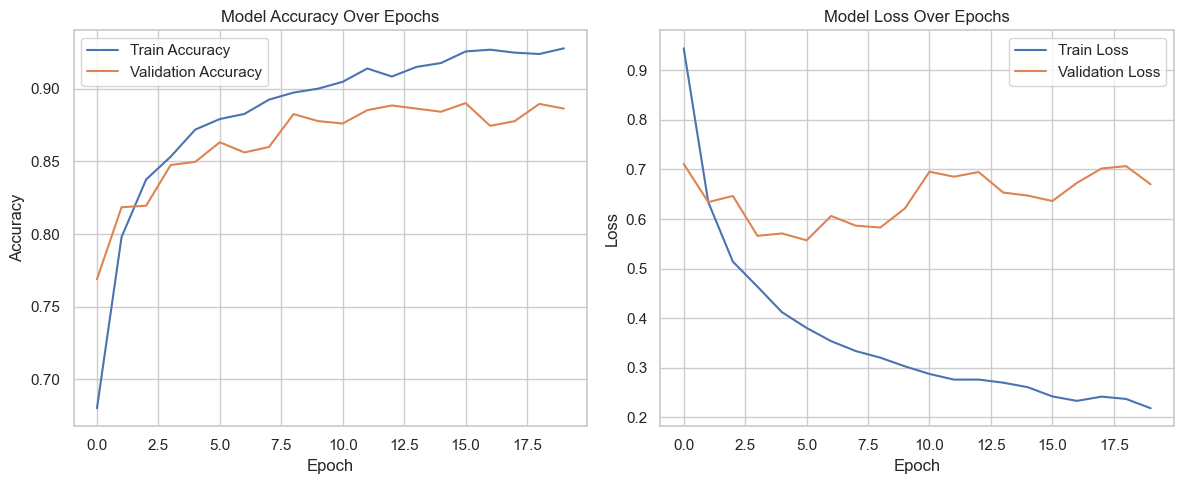

In [27]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [28]:
from sklearn.metrics import classification_report

# predicting class probabilities
y_pred_probs = model.predict(X_test_scaled)

# converting one-hot encoded predictions back to class indices(0-based)
y_pred_classes = y_pred_probs.argmax(axis=1)

# Convert back to [1–5] labels to match original
y_pred_final = y_pred_classes + 1

# Label map (same as before)
label_map = {
    1: "Adware",
    2: "Banking",
    3: "SMS",
    4: "Riskware",
    5: "Benign"
}
target_names = [label_map[i] for i in sorted(label_map)]

# Print classification report
print("Classification Report for DNN:\n")
print(classification_report(y_test, y_pred_final, target_names=target_names))

73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Classification Report for DNN:

              precision    recall  f1-score   support

      Adware       0.81      0.82      0.81       251
     Banking       0.85      0.86      0.85       420
         SMS       0.94      0.98      0.96       781
    Riskware       0.91      0.87      0.89       509
      Benign       0.92      0.85      0.88       359

    accuracy                           0.90      2320
   macro avg       0.88      0.88      0.88      2320
weighted avg       0.90      0.90      0.90      2320



In [29]:
# saving the model

model.save('dnn_model_apk.keras')

In [30]:
from sklearn.model_selection import train_test_split

#  simulating limited labeled data (20%) and unlabeled (80%)
X_labeled, X_unlabeled, y_labeled, _ = train_test_split(
    X_train_scaled, y_train,
    train_size=0.2,  # only 20% labeled
    stratify=y_train,
    random_state=42
)

print(f"Labeled samples: {X_labeled.shape[0]}")
print(f"Unlabeled samples (no labels used): {X_unlabeled.shape[0]}")


Labeled samples: 1855
Unlabeled samples (no labels used): 7423


In [33]:
import numpy as np

# Predicting probabilities for the unlabeled samples
pseudo_probs = model.predict(X_unlabeled)

# Getting max confidence and predicted classes
pseudo_confidences = np.max(pseudo_probs, axis=1)
pseudo_preds = np.argmax(pseudo_probs, axis=1) + 1  # shift back to [1–5] class labels

# Setting threshold (as in paper, 0.95 is typical)
confidence_threshold = 0.95

# Filter pseudo-labeled samples based on confidence
mask = pseudo_confidences >= confidence_threshold
X_pseudo = X_unlabeled[mask]
y_pseudo = pseudo_preds[mask]

print(f"Selected {len(X_pseudo)} high-confidence pseudo-labeled samples ✅")


232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step
Selected 5844 high-confidence pseudo-labeled samples ✅


In [35]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import  Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# merging the labeled and pseudo-labled data
X_combined = np.vstack((X_labeled,X_pseudo))
y_combined = np.concatenate((y_labeled,y_pseudo))

#  one-hot encoding
y_combined_oh = to_categorical(y_combined -1 , num_classes=5)

# defining a new model (same architecture as before)
pseudo_model = Sequential([
    Input(shape=(X_combined.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

# compiling the model
pseudo_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# training the model on the combined dataset

pseudo_history = pseudo_model.fit(
    X_combined, y_combined_oh,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=2
)



Epoch 1/20
193/193 - 2s - 9ms/step - accuracy: 0.7353 - loss: 0.8016 - val_accuracy: 0.9052 - val_loss: 0.3876
Epoch 2/20
193/193 - 0s - 3ms/step - accuracy: 0.8786 - loss: 0.4237 - val_accuracy: 0.9403 - val_loss: 0.2793
Epoch 3/20
193/193 - 0s - 2ms/step - accuracy: 0.9113 - loss: 0.3172 - val_accuracy: 0.9539 - val_loss: 0.2695
Epoch 4/20
193/193 - 0s - 2ms/step - accuracy: 0.9235 - loss: 0.2633 - val_accuracy: 0.9643 - val_loss: 0.2205
Epoch 5/20
193/193 - 0s - 2ms/step - accuracy: 0.9414 - loss: 0.2232 - val_accuracy: 0.9662 - val_loss: 0.2166
Epoch 6/20
193/193 - 0s - 2ms/step - accuracy: 0.9479 - loss: 0.1911 - val_accuracy: 0.9643 - val_loss: 0.2421
Epoch 7/20
193/193 - 0s - 2ms/step - accuracy: 0.9510 - loss: 0.1790 - val_accuracy: 0.9682 - val_loss: 0.2308
Epoch 8/20
193/193 - 0s - 2ms/step - accuracy: 0.9562 - loss: 0.1564 - val_accuracy: 0.9701 - val_loss: 0.2972
Epoch 9/20
193/193 - 0s - 2ms/step - accuracy: 0.9578 - loss: 0.1497 - val_accuracy: 0.9766 - val_loss: 0.2645
E

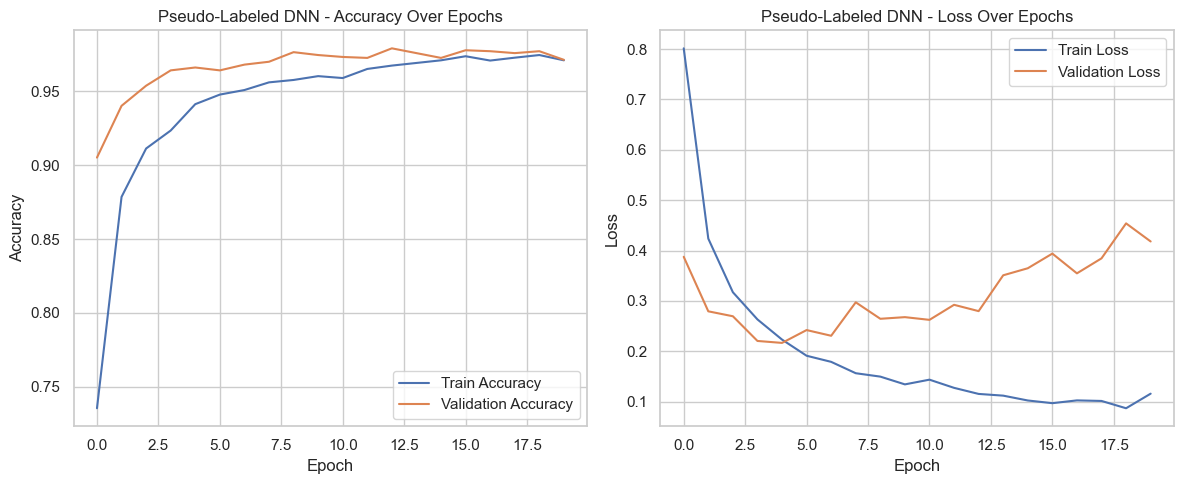

In [36]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(pseudo_history.history['accuracy'], label='Train Accuracy')
plt.plot(pseudo_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Pseudo-Labeled DNN - Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(pseudo_history.history['loss'], label='Train Loss')
plt.plot(pseudo_history.history['val_loss'], label='Validation Loss')
plt.title('Pseudo-Labeled DNN - Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [37]:
from sklearn.metrics import classification_report

# Predict on the test set
pseudo_test_probs = pseudo_model.predict(X_test_scaled)

# Convert probabilities to class predictions
pseudo_test_preds = np.argmax(pseudo_test_probs, axis=1) + 1  # shift from 0-based to 1–5

# Label mapping for readability
label_map = {
    1: "Adware",
    2: "Banking",
    3: "SMS",
    4: "Riskware",
    5: "Benign"
}
target_names = [label_map[i] for i in sorted(label_map)]

# Print report
print("Classification Report (Pseudo-Label DNN on Test Set):\n")
print(classification_report(y_test, pseudo_test_preds, target_names=target_names))


73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Classification Report (Pseudo-Label DNN on Test Set):

              precision    recall  f1-score   support

      Adware       0.83      0.81      0.82       251
     Banking       0.80      0.83      0.81       420
         SMS       0.94      0.97      0.95       781
    Riskware       0.88      0.85      0.87       509
      Benign       0.88      0.85      0.87       359

    accuracy                           0.88      2320
   macro avg       0.87      0.86      0.86      2320
weighted avg       0.88      0.88      0.88      2320



In [38]:
# Save the final pseudo-labeled DNN model
pseudo_model.save("pseudo_dnn_model.keras")
print("✅ Pseudo-labeled DNN model saved as 'pseudo_dnn_model.keras'")


✅ Pseudo-labeled DNN model saved as 'pseudo_dnn_model.keras'


<Figure size 800x600 with 0 Axes>

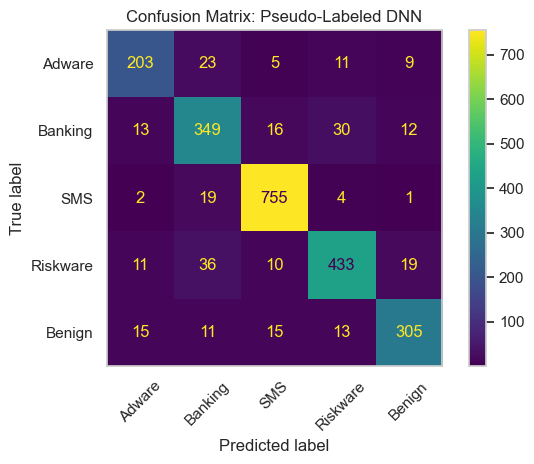


The confusion matrix visualizes the performance of the pseudo-labeled DNN model on the test dataset.
- Rows represent the true labels (actual classes).
- Columns represent the predicted labels (model's predictions).
- Each cell (i, j) shows the number of instances where the true label was i and the predicted label was j.
- Diagonal values (top-left to bottom-right) indicate correct predictions, while off-diagonal values represent misclassifications.
For example:
- The top-left cell shows the number of correctly classified 'Adware' samples.
- The bottom-right cell shows the number of correctly classified 'Benign' samples.     
- Off-diagonal cells, such as (1, 2), indicate 'Adware' samples misclassified as 'Banking'.
This graph helps identify which classes the model performs well on and where it struggles.



In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, pseudo_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

# Plot
plt.figure(figsize=(8, 6))
disp.plot(cmap='viridis', xticks_rotation=45)
plt.title("Confusion Matrix: Pseudo-Labeled DNN")
plt.grid(False)
plt.tight_layout()
plt.show()
print("""
The confusion matrix visualizes the performance of the pseudo-labeled DNN model on the test dataset.
- Rows represent the true labels (actual classes).
- Columns represent the predicted labels (model's predictions).
- Each cell (i, j) shows the number of instances where the true label was i and the predicted label was j.
- Diagonal values (top-left to bottom-right) indicate correct predictions, while off-diagonal values represent misclassifications.
For example:
- The top-left cell shows the number of correctly classified 'Adware' samples.
- The bottom-right cell shows the number of correctly classified 'Benign' samples.     
- Off-diagonal cells, such as (1, 2), indicate 'Adware' samples misclassified as 'Banking'.
This graph helps identify which classes the model performs well on and where it struggles.
""")
# End of the code
# Note: The code above is a complete example of a machine learning pipeline for malware classification using Random Forest and DNN models.